<b>Group Number:</b>  8
<br><b>Name Group Member 1:</b>  Arne Segatz
<br><b>u-Kürzel Group Member 1:</b>  urnye
<br><b>Name Group Member 2:</b> Anton Seifert 
<br><b>u-Kürzel Group Member 2:</b> unjud 

# Task 7.3: Introduction to Large Language Models (LLMs) 🎄

## Welcome to the North Pole AI Lab! 🎅

Ho Ho Ho! Welcome, aspiring Elves of Intelligence! You have successfully navigated through the snowy peaks of RNNs (Task 8.1) and the icy glaciers of Vision Transformers (Task 8.2). Now, grab a cup of hot cocoa, because things are about to get *chatty*.

In this notebook, we are leaving behind the character-by-character generation of yesteryear (sorry, LSTMs, you're on the nice list, but you're slow). We are diving into the world of **Large Language Models (LLMs)**—specifically, **Decoder-only Transformers**.

We will be working with **TinyLlama-1.1B**. Why "Tiny"? Because Santa's sleigh (and your GPU VRAM) has limits! But don't let the name fool you; this little model has read more internet text than you have eaten Christmas cookies.

### 🎯 Learning Goals (The Gift List)
1.  **Understand Autoregressive Language Modeling**: The mathematical foundation of text generation.
2.  **Master Tokenization**: From BPE to subword vocabularies.
3.  **Implement a Generation Loop**: Build a text generator from scratch.
4.  **Explore Sampling Strategies**: Temperature, Top-k, Top-p with mathematical intuition.
5.  **Understand Hallucinations**: Why LLMs lie with confidence.
6.  **Chat with an Elf**: Apply your knowledge in a fun roleplay exercise.

---
## 1. Theoretical Foundations: Autoregressive Language Modeling

Before we run any code, let's understand *what* a Large Language Model actually does.

### 1.1 The Goal: Modeling Probability of Text

An LLM is trained to model the probability of a sequence of words (or tokens). Given a sequence $\mathbf{w} = (w_1, w_2, \ldots, w_T)$, the model learns:

$$P(\mathbf{w}) = P(w_1, w_2, \ldots, w_T)$$

Using the **chain rule of probability**, we can decompose this as:

$$P(\mathbf{w}) = P(w_1) \cdot P(w_2 | w_1) \cdot P(w_3 | w_1, w_2) \cdots P(w_T | w_1, \ldots, w_{T-1})$$

Or more compactly:

$$P(\mathbf{w}) = \prod_{t=1}^{T} P(w_t | w_{<t})$$

where $w_{<t} = (w_1, \ldots, w_{t-1})$ denotes all tokens before position $t$.

This is called **Autoregressive Language Modeling**: the model predicts one token at a time, conditioned on all previous tokens.

<p align="center">
  <img src="https://miro.medium.com/v2/resize:fit:720/format:webp/1*kldme79aJx6Ki4yxiOPoig.png" width="60%" height="auto"/>
  <br>
  <em>Figure 1: Autoregressive prediction. Each token depends on all previous tokens.</em>
</p>

### 1.2 Causal Masking: Why LLMs Only Look Left

In Task 8.2, you learned about the **Attention Mechanism**. In a standard Transformer encoder (like BERT or ViT), each token can attend to *all* other tokens in the sequence (bidirectional attention).

However, for **text generation**, this would be cheating! If the model could see future tokens while predicting, it would just copy them. Therefore, LLMs use **Causal Masking** (also called "Masked Self-Attention").

The causal mask is a triangular matrix that prevents token $t$ from attending to any token $t' > t$:

$$\text{Mask}_{t, t'} = \begin{cases} 0 & \text{if } t' \leq t \\ -\infty & \text{if } t' > t \end{cases}$$

When this mask is added to the attention scores (before softmax), the $-\infty$ values become 0 after softmax, effectively zeroing out attention to future tokens.

<p align="center">
  <img src="https://miro.medium.com/v2/resize:fit:720/format:webp/0*AZ9q71zKfSVgw0Qe.png" width="40%" height="auto"/>
  <br>
  <em>Figure 2: Input token embedding (left) and causal (triangular) attention mask (right).</em>
</p>

> **Key Insight 🧠**: This is the fundamental difference between **Encoder-only** models (BERT, ViT) and **Decoder-only** models (GPT, LLaMA, TinyLlama). Decoders are *generative* because they are trained to predict the next token without peeking.

<div class="alert alert-block alert-success">
<b>Question 1.1 (1 pt):</b> In Task 8.2, you built a Vision Transformer (ViT) for image classification. Did the ViT use causal masking? Why or why not? How would a ViT's behavior change if you added a causal mask?
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b>



</div>

---
## 2. Setup: Checking the Sleigh 🛷

Let's import our tools. We'll be using `transformers` (the Hugging Face library) and `torch`.

In [2]:
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt
import numpy as np
import time

# Determine if we have a Lama warp drive (CUDA) or reindeer power (CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🛷 Sleigh powered by: {device.upper()}")

if device == "cpu":
    print("⚠️ Warning: Reindeer power is slow for generation. Be patient!")

🛷 Sleigh powered by: CPU
⚠️ Warning: Reindeer power is slow for generation. Be patient!


## 3. Loading the Model 🎁

We are using `TinyLlama/TinyLlama-1.1B-Chat-v1.0`. It's a 1.1 Billion parameter model. That sounds huge, but in the world of LLMs, it's basically a toddler. For comparison, GPT-4 is rumored to have over 1 *trillion* parameters.

> **Side Note 📝 (Memory Math)**: We load the model in `float16` (half precision) if on GPU. A full 32-bit float takes 4 bytes. So: 1.1 billion params × 4 bytes ≈ 4.4 GB. In float16, it's ~2.2 GB. Fits easily in an 8GB stocking!

In [3]:
model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

print("📥 Downloading the dictionary (Tokenizer)...")
tokenizer = AutoTokenizer.from_pretrained(model_id)

print("🎁 Unwrapping the brain (Model)... (This takes a moment)")
dtype = torch.float16 if device == "cuda" else torch.float32
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=dtype)
model.to(device)
model.eval()  # Set to evaluation mode

print(f"✅ Model loaded! Parameters: {sum(p.numel() for p in model.parameters()):,}")

📥 Downloading the dictionary (Tokenizer)...
🎁 Unwrapping the brain (Model)... (This takes a moment)


`torch_dtype` is deprecated! Use `dtype` instead!
c:\Users\arnes\miniconda3\envs\lama25-env\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

c:\Users\arnes\miniconda3\envs\lama25-env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\arnes\.cache\huggingface\hub\models--TinyLlama--TinyLlama-1.1B-Chat-v1.0. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ Model loaded! Parameters: 1,100,048,384


---
## 4. Tokenization: From Text to Numbers 🔢

Neural networks don't understand text—they understand numbers. The **Tokenizer** is the bridge:

$$\text{"Hello world"} \xrightarrow{\text{Tokenizer} } [15496, 995] \xrightarrow{\text{Model} } \text{logits}$$

### 4.1 What is a Token?

A token is *not* always a word. Modern tokenizers use **subword tokenization**. Common words like "the" or "Christmas" are single tokens, but rare words like "Supercalifragilisticexpialidocious" are split into multiple subword pieces.

### 4.2 Byte Pair Encoding (BPE)

Most modern LLMs (including TinyLlama, GPT, LLaMA) use a variant of **Byte Pair Encoding (BPE)**.

**The BPE Algorithm (Simplified):**
1.  Start with a vocabulary of individual characters (e.g., `a`, `b`, `c`, ...).
2.  Count all pairs of adjacent tokens in the training corpus.
3.  Merge the most frequent pair into a new token (e.g., `t` + `h` → `th`).
4.  Repeat steps 2-3 until the vocabulary reaches the desired size (e.g., 32,000 tokens).

**Result**: Common words become single tokens. Rare words are broken into known subwords. This balances vocabulary size against the ability to represent any text.

<p align="center">
  <img src="https://cdn-images-1.medium.com/max/800/1*jCHBfRMrbjgn5WJtGdigvQ.png" width="70%" height="auto"/>
  <br>
  <em>Figure 3: Tokenizing with different dictionairy sizes. Frequent combinations are tokenized first.</em>
</p>

> **Why not just use words?** English has hundreds of thousands of words. New words are invented constantly. A word-level vocabulary would be massive, and any new word would be "unknown". BPE can represent *any* string using its learned subwords.

In [4]:
# Let's see tokenization in action
text = "Santa's reindeer love quantum physics and Supercalifragilisticexpialidocious."
inputs = tokenizer(text, return_tensors="pt")

print(f"📜 Original Text: \"{text}\"")
print(f"🔢 Token Count: {len(inputs.input_ids[0])}")
print(f"📊 Word Count: {len(text.split())}")
print("\n🔍 Token Breakdown:")
for token_id in inputs.input_ids[0]:
    decoded = tokenizer.decode(token_id)
    print(f"  ID {token_id:5} -> '{decoded}'")

📜 Original Text: "Santa's reindeer love quantum physics and Supercalifragilisticexpialidocious."
🔢 Token Count: 23
📊 Word Count: 7

🔍 Token Breakdown:
  ID     1 -> '<s>'
  ID  7510 -> 'Santa'
  ID 29915 -> '''
  ID 29879 -> 's'
  ID 15561 -> 'rein'
  ID   311 -> 'de'
  ID   261 -> 'er'
  ID  5360 -> 'love'
  ID 12101 -> 'quantum'
  ID 17558 -> 'physics'
  ID   322 -> 'and'
  ID  5670 -> 'Super'
  ID  1052 -> 'cal'
  ID   361 -> 'if'
  ID  1431 -> 'rag'
  ID   309 -> 'il'
  ID   391 -> 'ist'
  ID   625 -> 'ice'
  ID 26330 -> 'xp'
  ID   616 -> 'ial'
  ID  1941 -> 'ido'
  ID  8802 -> 'cious'
  ID 29889 -> '.'


<div class="alert alert-block alert-success">
<b>Student Task 4.1 (1 pt):</b> Using the tokenizer, find out how many tokens the following two sentences have. Why is there such a big difference?
</div>

In [5]:
sentence_a = "The cat sat on the mat."
sentence_b = "Pneumonoultramicroscopicsilicovolcanoconiosis is a lung disease."

# STUDENT CODE HERE


# STUDENT CODE until HERE

<details>
<summary><b>Hint 🎅</b></summary>
Use <code>len(tokenizer(sentence).input_ids)</code> to count tokens.
</details>

<div class="alert alert-block alert-success">
<b>Question 4.2 (1 pt):</b> TinyLlama has a vocabulary size of 32,000 tokens. If we used a word-level tokenizer instead (one token per English word), we might need 500,000+ tokens. What are two disadvantages of such a large vocabulary for a neural network?
</div>


<div class="alert alert-block alert-success">
<b>Your Answer:</b>



</div>

---
## 5. The Generation Loop: Building a Text Generator from Scratch ⚒️

Now for the fun part. Let's implement text generation *manually* to understand exactly what `model.generate()` does under the hood.

### 5.1 Greedy Decoding

The simplest strategy: at each step, pick the token with the **highest probability**.

$$w_t = \arg\max_{w} P(w | w_{<t})$$

**Algorithm:**
1.  Tokenize the prompt.
2.  Pass tokens through the model → get logits (unnormalized scores for each vocabulary token).
3.  Take the logits for the *last* position (we're predicting the *next* token).
4.  Apply `argmax` to find the highest-scoring token ID.
5.  Append this token to the input sequence.
6.  Repeat until we hit an End-of-Sequence (EOS) token or max length.

In [6]:
def generate_greedy(model, tokenizer, prompt, max_new_tokens=30):
    """
    Manually implement greedy decoding.
    """
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    input_ids = inputs.input_ids

    print(f"🧝 Prompt: \"{prompt}\"")
    print("🧝 Generating: ", end="")

    # STUDENT CODE HERE (2 pts)


    # STUDENT CODE until HERE

    print("\n✅ Done!")
    return tokenizer.decode(input_ids[0], skip_special_tokens=True)

# Test it!
_ = generate_greedy(model, tokenizer, "For Christmas, I want")

🧝 Prompt: "For Christmas, I want"
🧝 Generating: 
✅ Done!


> **Why is greedy decoding problematic?** 🧠
>
> Greedy decoding often gets stuck in **repetition loops**. If the most likely word after "I don't" is "know", and the most likely word after "I don't know" is "I", you get: "I don't know I don't know I don't know...".
>
> Real LLMs use sampling with penalties to avoid this.

---
## 6. Sampling Strategies: The Mathematics of Creativity ✨

Greedy decoding is deterministic and boring. To get creative text, we **sample** from the probability distribution instead of always picking the maximum.

### 6.1 From Logits to Probabilities

The model outputs **logits** $z_i$ for each token $i$ in the vocabulary. To convert these to probabilities, we apply the **softmax** function:

$$P(w_i | w_{<t}) = \frac{e^{z_i} }{\sum_{j=1}^{V} e^{z_j} }$$

where $V$ is the vocabulary size.

### 6.2 Temperature Scaling

**Temperature** ($T$) is a hyperparameter that controls the "sharpness" of the distribution:

$$P(w_i | w_{<t}; T) = \frac{e^{z_i / T} }{\sum_{j=1}^{V} e^{z_j / T} }$$

- **$T \to 0$**: Distribution becomes sharper. The highest-scoring token dominates (approaches greedy).
- **$T = 1$**: Standard softmax (no change).
- **$T \to \infty$**: Distribution becomes uniform. All tokens equally likely (pure randomness).

Let's visualize this!

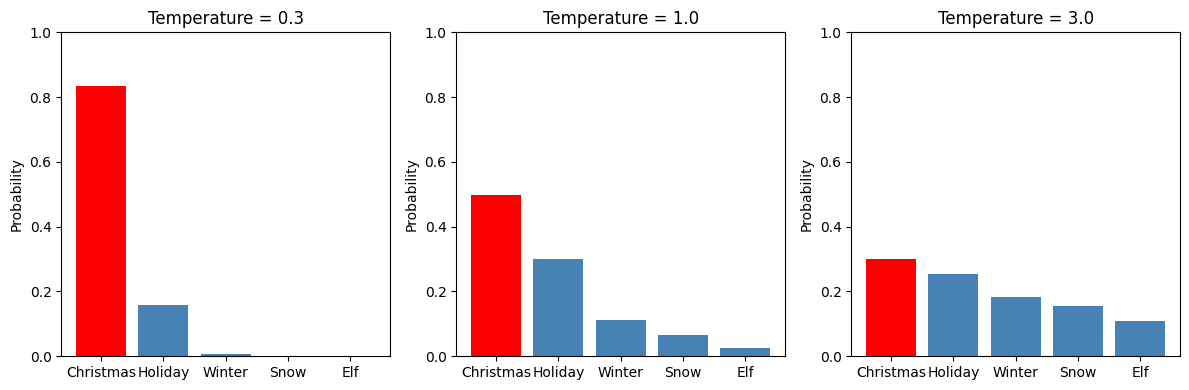

In [7]:
# Visualize temperature effects
def softmax_with_temperature(logits, temperature):
    scaled = logits / temperature
    return F.softmax(scaled, dim=-1)

# Example logits (pretend these are scores for 5 tokens)
example_logits = torch.tensor([2.0, 1.5, 0.5, 0.0, -1.0])
token_labels = ["Christmas", "Holiday", "Winter", "Snow", "Elf"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
temperatures = [0.3, 1.0, 3.0]

for ax, T in zip(axes, temperatures):
    probs = softmax_with_temperature(example_logits, T).numpy()
    ax.bar(token_labels, probs, color=['red' if p == max(probs) else 'steelblue' for p in probs])
    ax.set_title(f"Temperature = {T}")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

### 6.3 Top-k and Top-p (Nucleus) Sampling

Even with temperature, low-probability tokens can still be sampled (leading to nonsense). To fix this:

**Top-k Sampling**: Only consider the $k$ highest-scoring tokens. Set all others to probability 0.

**Top-p (Nucleus) Sampling**: Sort tokens by probability. Keep the smallest set of tokens whose cumulative probability exceeds $p$ (e.g., 0.9). This adapts dynamically—sometimes 5 tokens cover 90%, sometimes 50.

$$\text{Top-p}: \quad \sum_{i \in \text{nucleus} } P(w_i) \geq p$$

In [8]:
def generate_with_sampling(prompt, temperature=0.7, top_k=50, top_p=0.9, max_new_tokens=50):
    """
    Use the built-in generate() with sampling.
    """
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    
    print(f"🔮 T={temperature}, top_k={top_k}, top_p={top_p}")
    print(f"📜 Prompt: {prompt}")
    
    with torch.no_grad():
        output_ids = model.generate(
            inputs.input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            pad_token_id=tokenizer.eos_token_id
        )
    
    result = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    print(f"📝 Output: {result}")
    print("-" * 50)
    return result

prompt = "On Christmas Eve, the strangest thing happened:"

# Conservative (low temp, focused)
_ = generate_with_sampling(prompt, temperature=0.3)

# Balanced (recommended for most uses)
_ = generate_with_sampling(prompt, temperature=0.7)

# Creative/Chaotic (high temp)
_ = generate_with_sampling(prompt, temperature=1.5)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


🔮 T=0.3, top_k=50, top_p=0.9
📜 Prompt: On Christmas Eve, the strangest thing happened:
📝 Output: On Christmas Eve, the strangest thing happened: a group of strangers from different walks of life came together to sing Christmas carols. The group included a retired couple, a young couple on their first date, a group of teenagers, a retired couple, and a young couple on
--------------------------------------------------
🔮 T=0.7, top_k=50, top_p=0.9
📜 Prompt: On Christmas Eve, the strangest thing happened:
📝 Output: On Christmas Eve, the strangest thing happened: the moon turned red. The sky was ablaze with colors, and the people of the town couldn't believe it. The moon had turned red, and it lasted for hours. The people who had seen it said that it was a
--------------------------------------------------
🔮 T=1.5, top_k=50, top_p=0.9
📜 Prompt: On Christmas Eve, the strangest thing happened:
📝 Output: On Christmas Eve, the strangest thing happened: My family and I found ourselves sitting a

<div class="alert alert-block alert-success">
<b>Question 6.1 (1 pt):</b> Mathematically, what happens to the softmax output when T -> 0? What is the relationship between T=0 and argmax (greedy decoding)?
</div>


<div class="alert alert-block alert-success">
<b>Your Answer:</b>



</div>

<details>
<summary><b>Hint 🎅</b></summary>
Consider: lim_(T->0) e^z_i / T for the largest z_i vs. smaller values. What dominates?
</details>

<div class="alert alert-block alert-success">
<b>Student Task 6.2 (1 pt):</b> Run the cell below with <code>temperature=5.0</code>. Describe what happens to the output and explain why based on the softmax formula.
</div>

In [9]:
# STUDENT CODE HERE: Change temperature to 5.0 and observe


# STUDENT CODE until HERE

<div class="alert alert-block alert-success">
<b>Your Answer:</b>



</div>

---
## 7. Hallucinations: The Confident Liar 🔮

LLMs are often called **Stochastic Parrots**. They don't "know" facts—they predict statistically likely continuations based on training data.

**Hallucination** occurs when the model generates confident-sounding but factually incorrect (or entirely made-up) information.

### 7.1 Why Do LLMs Hallucinate?

1.  **Training Data Cutoff**: The model doesn't know about events after its training date.
2.  **No Fact Verification**: The model doesn't "look up" facts. It generates based on patterns.
3.  **Overconfidence**: The training objective rewards fluent text, not truthful text.

Let's ask TinyLlama about something it *cannot* know:

In [10]:
# Ask about a future event
_ = generate_with_sampling(
    "In December 2030, the first human colony on Mars celebrated Christmas by",
    temperature=0.8
)

🔮 T=0.8, top_k=50, top_p=0.9
📜 Prompt: In December 2030, the first human colony on Mars celebrated Christmas by
📝 Output: In December 2030, the first human colony on Mars celebrated Christmas by lighting a Christmas tree in the crater where the settlement was built.

2. Astronaut's Christmas Tree: On December 21, 2019, NASA astronauts Christina Koch and Jessica Me
--------------------------------------------------


> **Did it say "I don't know"?** Probably not. It likely invented a plausible-sounding story. This is a hallucination.

<div class="alert alert-block alert-success">
<b>Question 7.1 (1 pt):</b> Imagine you are building a customer support chatbot using an LLM. A customer asks: "What is the exact price of Product X?" Why is using an LLM to answer this risky? What are two techniques you could use to reduce the risk of hallucinated prices?
</div>


<div class="alert alert-block alert-success">
<b>Your Answer:</b>



</div>

---
## 8. Chat Templates: Talking to the Elf 🧝‍♂️

TinyLlama is a **Chat Model**. It was fine-tuned on conversations with specific roles: `system`, `user`, `assistant`.

To get good results, we must format our input using the model's expected **chat template**. The tokenizer handles this for us.

### 8.1 The System Prompt

The **system prompt** sets the model's persona and behavior. It's like giving stage directions to an actor.

In [11]:
def chat_with_elf(user_message, system_prompt=None):
    """
    Chat with the model using proper chat formatting.
    """
    if system_prompt is None:
        system_prompt = (
            "You are Alabaster Snowball, a very overworked and grumpy elf at the North Pole. "
            "It is 11:59 PM on Christmas Eve. You just want to go to sleep. "
            "You are sarcastic and rude, but ultimately helpful. Keep responses short."
        )
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_message},
    ]
    
    # Apply the chat template
    prompt = tokenizer.apply_chat_template(
        messages, 
        tokenize=False, 
        add_generation_prompt=True
    )
    
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    
    with torch.no_grad():
        output_ids = model.generate(
            inputs.input_ids,
            max_new_tokens=150,
            do_sample=True,
            temperature=0.7,
            pad_token_id=tokenizer.eos_token_id
        )
    
    response = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    # Extract just the assistant's reply (after the last user message)
    response = response.split(user_message)[-1].strip()
    
    print(f"👤 You: {user_message}")
    print(f"🧝 Alabaster: {response}")
    return response

# Try it!
_ = chat_with_elf("I want a pony for Christmas! Pretty please?")

👤 You: I want a pony for Christmas! Pretty please?
🧝 Alabaster: <|assistant|>
Boo! You're asking too much. Pony gifts are not as popular as they used to be. But you can always dream, right? How about a magical unicorn with rainbows and sparkles? It would be a perfect match for your snowy Christmas.

Hope this helps, and Happy Holidays!

Best regards,
[Your Name]
[Your Position]
[Your Company]


<div class="alert alert-block alert-success">
<b>Student Task 8.1 (1 pt):</b> Modify the system prompt to make the elf extremely cheerful and helpful instead of grumpy. Run your modified version and paste the response below.
</div>

In [12]:
# STUDENT CODE HERE


# STUDENT CODE until HERE

<div class="alert alert-block alert-success">
<b>Your Response:</b>

{{*(Sample - actual response will vary due to sampling)*

🧝 Jingles McSparkle: OH MY JINGLE BELLS! A PONY?! 🐴✨ That is absolutely WONDERFUL! Santa and I are going to work SO hard to make your Christmas dreams come true! Have you been good this year? Of course you have! I can just FEEL the Christmas spirit radiating from your message! 🎄🎁 Let me check with the reindeer team - maybe they know a friendly pony who wants a loving home! Merry Christmas, friend! 🎅❤️}}
</div>

---
## 9. Reflection: What Have We Learned? ❄️

Congratulations! You've reached the end of Task 8. Let's reflect on the journey.

<div class="alert alert-block alert-success">
<b>Reflection 9.1 (2 pts):</b> Compare your experience with the LSTM in Task 8.1 vs. TinyLlama here. Which one produced more "human-like" text? Based on what you learned about attention vs. recurrence, why do you think Transformers are better at maintaining context over long sequences?
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b>



</div>

<div class="alert alert-block alert-success">
<b>Reflection 9.2 (2 pts):</b> An LLM like TinyLlama has no "working memory" between conversations—it forgets everything after the context window ends. Describe one real-world application where this is a major limitation, and propose a simple engineering solution (not a model change) to work around it.
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b>



</div>

---
## 🎄 Merry Christmas and Happy Coding! 🎄

You have successfully completed Task 8. You've:
- Trained RNNs and LSTMs from scratch
- Built a Vision Transformer for image classification
- Explored the inner workings of Large Language Models

Don't just consume AI—understand it, break it, and build something better.

*(And maybe apologize to Alabaster the Elf for keeping him up so late.)*

---
### References

1. Vaswani et al., "Attention Is All You Need", NeurIPS 2017
2. Radford et al., "Language Models are Unsupervised Multitask Learners", OpenAI 2019
3. Sennrich et al., "Neural Machine Translation of Rare Words with Subword Units", ACL 2016
4. Holtzman et al., "The Curious Case of Neural Text Degeneration", ICLR 2020